In [1]:
!pip install --quiet casadi

In [2]:
import numpy as np
from kinetics import *
import time

In [12]:
constants = {
# v1: PTS (Sistema de fosfotransferasa)
"kI_pyr_1": 0.5,  # Inhibición por piruvato
"kA_pep_1": 0.3,  # Afinidad/Activación por PEP
"v_max_1": 25.739,  # Flujo máximo típico en fase exponencial
"Ka1_1": 1.0,  # Parámetros de la ecuación compleja del PTS
"Ka2_1": 0.01,
"Ka3_1": 1.0,
"n_g6p_1": 4,  # Cooperatividad/Regulación por G6P
"K_g6p_1": 0.5,
# v2: PGI (Glucosa-6-fosfato isomerasa)
"kI_pep_2": 0.12,  # Fuerte inhibición por PEP
"Km_g6p_2": 0.48,
"Km_f6p_2": 0.19,
"kcat_f_2": 1475.0,  # Reacción muy rápida
"kcat_r_2": 1000.0,
# v3: PFK (Fosfofructoquinasa) - Enzima regulatoria clave
"kI_f6p_3": 0.9,
"kI_fbp_3": 2.0,
"kI_gtp_3": 0.8,
"kI_pep_3": 0.5,  # Inhibidor alostérico principal
"kI_pi_3": 1.5,
"kA_adp_3": 0.12,  # Activador alostérico
"kA_gdp_3": 0.15,
"Km_f6p_3": 0.16,
"Km_atp_3": 0.12,
"Km_fbp_3": 0.5,
"Km_adp_3": 0.2,
"kcat_f_3": 580.0,
"kcat_r_3": 100.0,
# v4: FBA (Fructosa-bisfosfato aldolasa)
"kI_3pg_4": 2.0,
"kI_dhap_4": 0.08,
"kI_g3p_4": 0.1,
"kA_pep_4": 1.5,
"kcat_f_4": 95.0,
"kcat_r_4": 150.0,
"Km_fbp_4": 0.3,
"Km_g3p_4": 0.4,
"Km_dhap_4": 2.0,
# v5: TPI (Triosafosfato isomerasa)
"kcat_f_5": 4300.0,  # Cercana a la perfección catalítica
"kcat_r_5": 2400.0,
"Km_dhap_5": 0.61,
"Km_g3p_5": 1.2,
# v6: GAPDH (Gliceraldehído-3-fosfato deshidrogenasa)
"kI_adp_6": 0.8,
"kI_amp_6": 1.0,
"kI_atp_6": 0.2,
"kcat_f_6": 118.0,
"kcat_r_6": 10.0,
"Km_g3p_6": 0.21,
"Km_pi_6": 0.29,
"Km_nad_6": 0.09,
"Km_pgp_6": 0.01,
"Km_nadh_6": 0.06,
# v7: PGK (Fosfoglicerato quinasa)
"kA_3pg_7": 0.5,
"kA_atp_7": 0.3,
"kcat_f_7": 1150.0,
"kcat_r_7": 40.0,
"Km_pgp_7": 0.05,
"Km_adp_7": 0.1,
"Km_3pg_7": 0.53,
"Km_atp_7": 0.3,
# v8: GPM (Fosfoglicerato mutasa)
"kI_pi_8": 10.0,  # Inhibición débil por Pi
"kcat_f_8": 540.0,
"kcat_r_8": 120.0,
"Km_3pg_8": 0.2,
"Km_2pg_8": 1.4,
# v9: ENO (Enolasa)
"kcat_f_9": 550.0,
"kcat_r_9": 210.0,
"Km_2pg_9": 0.1,
"Km_pep_9": 0.5,
}
metabolites = {
# balanced
"C_2pg": 2.84e-5,
"C_3pg": 4.52e-4,
"C_dhap": 4.48e-6,
"C_f6p": 3.53e-5,
"C_fbp": 3.42e-5,
"C_g3p": 4.23e-7,
"C_g6p": 2.45e-4,
"C_pep": 1.02e-4,
"C_pgp": 2.56e-6,
# fixed
"C_atp": 0.1,
"C_adp": 0.01,
"C_amp": 0.01,
"C_gdp": 0.01,
"C_glc": 0.01,
"C_gtp": 0.01,
"C_nad": 0.01,
"C_nadh": 0.01,
"C_pi": 0.01,
"C_pyr": 0.01,
}
enzymes = {
"Pgi": 0.01,
"PfkB": 0.1,
"FbaA": 0.1,
"TpiA": 0.1,
"GapA": 0.1,
"Pgk": 0.01,
"GpmA": 0.1,
"Eno": 0.1,
}
model = EcoliCarbonKinetics(metabolites, enzymes, constants)
opts = {                                                                                                                 
"max_num_steps": 1e100,                                                                                            
"constraints": [1, 1, 1, 1, 1, 1, 1, 1, 1],
"reltol": 1e-10,                                                                                                      
"abstol": 1e-8,                                                                                                      
}   
times = []
for _ in range(10):
    ti = time.time()
    model.simulate_system(tspan=(0, 10000), opts=opts)
    tf = time.time()
    times.append(tf - ti)
print(f"Average simulation time: {np.mean(times):.4f} ± {np.std(times):.4f} seconds")
    
t, sol = model.simulate_system(tspan=(0, 10000), opts=opts)


Average simulation time: 0.0195 ± 0.0069 seconds


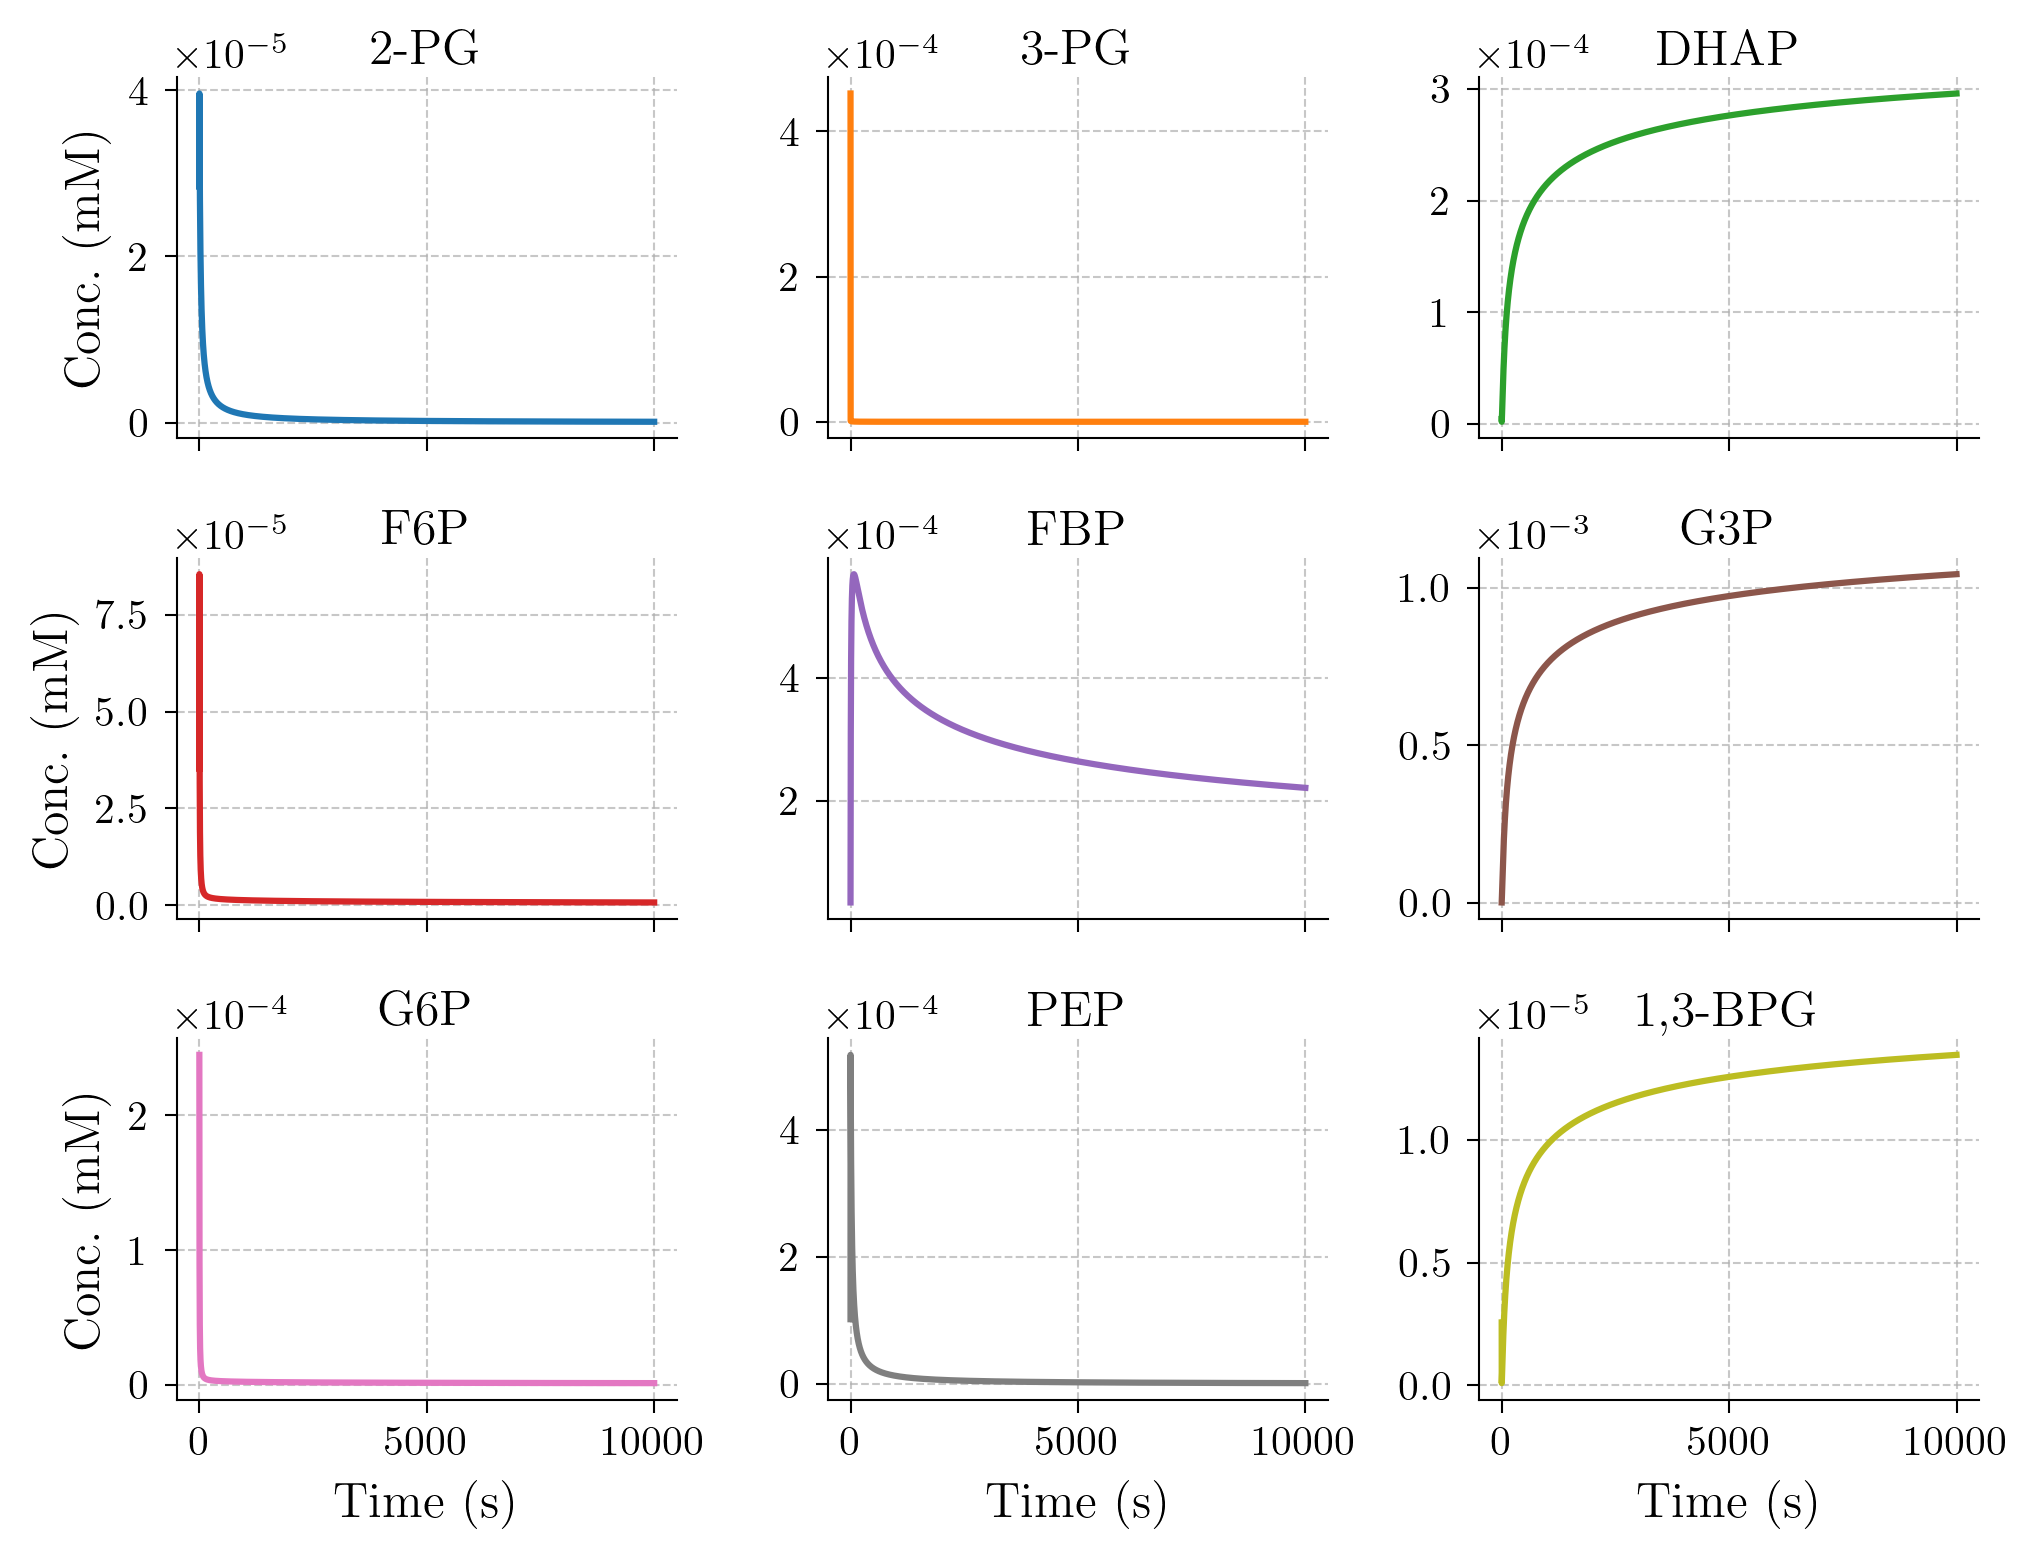

In [13]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "lines.linewidth": 0.9,
    "axes.linewidth": 0.5,
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
})

MET_TEX = {
    "2pg":  r"2-PG",
    "3pg":  r"3-PG",
    "dhap": r"DHAP",
    "f6p":  r"F6P",
    "fbp":  r"FBP",
    "g3p":  r"G3P",
    "g6p":  r"G6P",
    "pep":  r"PEP",
    "pgp":  r"1,3-BPG",
}

tspan = np.linspace(t[0], t[-1], 10000)
mets = list(model.stoichiometric_matrix.index)

fig, axes = plt.subplots(
    3, 3,
    figsize=(6.8, 5.2),
    dpi=300,
    sharex=True,
)
# fig.suptitle(
#     r"\textit{E.~coli} glycolysis --- metabolite dynamics",
#     fontsize=8,
#     y=1.01,
# )

colors = plt.cm.tab10.colors

for i, met in enumerate(mets):
    row, col = divmod(i, 3)
    ax = axes[row, col]
    res = sol.iloc[:, i]
    ax.plot(tspan, res, color=colors[i], linewidth = 1.5)
    ax.set_title(MET_TEX.get(met, met), pad=3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.ticklabel_format(style="sci", axis="y", scilimits=(-3, 3))
    ax.yaxis.get_offset_text().set_fontsize(10)
    if row == 2:
        ax.set_xlabel(r"Time (s)")
    if col == 0:
        ax.set_ylabel(r"Conc.\ (mM)")
    ax.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.7)

fig.tight_layout(pad=0.6, h_pad=1.2, w_pad=0.8)
plt.savefig("glycolysis_dynamics.pdf", bbox_inches="tight")
plt.show()

/var/folders/d4/fcz_093s76vfkprz49zjtkmc0000gn/T/ipykernel_74968/1274053562.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(RXNS_TEX, rotation=45, ha="right")


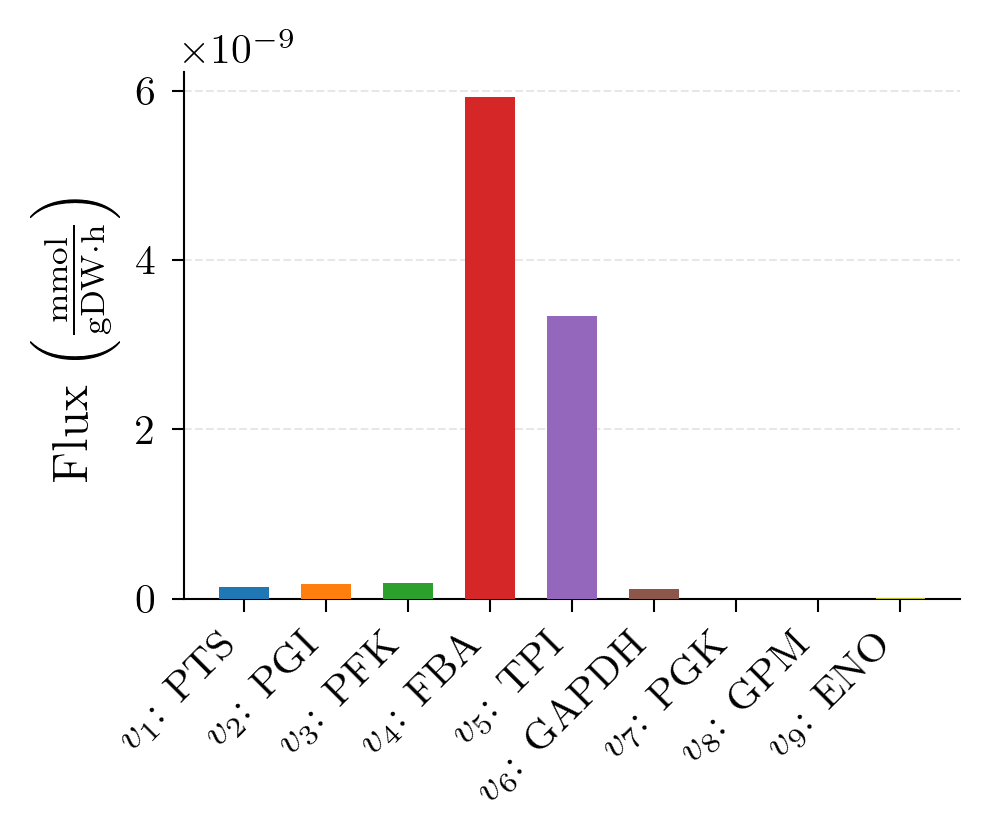

In [14]:
concentrations_ss = sol.iloc[-1, :].to_dict()
metabolites.update(concentrations_ss)

fluxes = model.compute_fluxes(metabolites)

RXNS_TEX = [
    r"$v_1$: PTS",
    r"$v_2$: PGI",
    r"$v_3$: PFK",
    r"$v_4$: FBA",
    r"$v_5$: TPI",
    r"$v_6$: GAPDH",
    r"$v_7$: PGK",
    r"$v_8$: GPM",
    r"$v_9$: ENO",
]

# single-column width for a two-column LaTeX document (~3.3 in)
fig, ax = plt.subplots(figsize=(3.3, 2.8), dpi=300)
ax.grid(alpha=0.3, axis="y", linestyle="--", linewidth=0.5, zorder=1)
ax.bar(RXNS_TEX, fluxes, color=colors[:len(fluxes)], width=0.6, zorder=4)
ax.set_ylabel(
    r"Flux $\left(\frac{\mathrm{mmol}}{\mathrm{gDW} \cdot \mathrm{h}}\right)$"
)
ax.set_xticklabels(RXNS_TEX, rotation=45, ha="right")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
fig.tight_layout(pad=0.6)
fig.savefig("glycolysis_fluxes.pdf", bbox_inches="tight")
plt.show()


In [ ]:
fluxes

array([1.39392938e-10, 1.71999289e-10, 1.91036032e-10, 5.92760353e-09,
       3.33360863e-09, 1.18441140e-10, 3.38955099e-13, 6.51436400e-13,
       1.04945868e-11])

In [ ]:
metabolites

{'C_2pg': 9.879480967497253e-08,
 'C_3pg': 3.136345579425187e-09,
 'C_dhap': 0.00029592177558636736,
 'C_f6p': 7.32027271272942e-07,
 'C_fbp': 0.00022105693460518355,
 'C_g3p': 0.0010430029628351045,
 'C_g6p': 1.2537900405765508e-06,
 'C_pep': 1.2937413053954892e-06,
 'C_pgp': 1.3472820780922543e-05,
 'C_atp': 0.1,
 'C_adp': 0.01,
 'C_amp': 0.01,
 'C_gdp': 0.01,
 'C_glc': 0.01,
 'C_gtp': 0.01,
 'C_nad': 0.01,
 'C_nadh': 0.01,
 'C_pi': 0.01,
 'C_pyr': 0.01}